# Analyse Experiment Results #

In [1]:
import os
import ast
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

## Analyse Dataset Selection Experiments with Negative Sampling & Smoothing Factor using Cold Start Setting ##

In [2]:
## util methods ##

def parse_cell(x):
    """
    Convert a cell into a Python object.
    Handles cases where the cell is already a list
    or stored as a string representation of a list.
    """
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return None
    if isinstance(x, str):
        x = x.strip()
        try:
            return ast.literal_eval(x)
        except Exception:
            try:
                return json.loads(x)
            except Exception:
                return None
    return x


def avg_fold_metrics(fold_value):
    """
    fold_value should be a list of 10 sublists, each sublist like:
    [auc, aupr, precision, sensitivity, specificity]

    Returns:
    [avg_auc, avg_aupr, avg_precision, avg_sensitivity, avg_specificity]
    """
    fold_value = parse_cell(fold_value)

    if not fold_value:
        return [np.nan] * 5

    arr = np.array(fold_value, dtype=float)   # shape should be (10, 5)
    return [round(x, 5) for x in arr.mean(axis=0).tolist()]

In [23]:
EXP_0303_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0103_full_.csv'
EXP_0803_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0803.csv'
EXP_0903_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0903.csv'
EXP_1003_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_1003.csv'
EXP_1203_VPATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_1203.csv' # VICTOR
EXP_1503_VPATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_eval_neg_smoo_1503.csv' # VICTOR

# preprocessed csv files name - for saving preprocessed results 
PREPROCESSED_EXP_0303_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0103_full_preprocessed_.csv'
PREPROCESSED_EXP_0803_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0803_full_preprocessed_.csv'
PREPROCESSED_EXP_0903_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_0903_full_preprocessed_.csv'
PREPROCESSED_EXP_1203_PATH = '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/cold_eval_neg_smoo_1203_full_preprocessed_.csv'
PREPROCESSED_EXP_1503_PATH =  '/home/gavrilev/DLResearchPPI/PPI Research/src_/results/result_tables/final_results/cold_eval_neg_smoo_1503full_preprocessed_.csv'

In [8]:
exp_df = pd.read_csv(EXP_1503_VPATH)
exp_df

,exp,val_res,fold1,fold2,fold3,fold4,fold5
0,dataset_neg_fct_5_smoo_fct_0.9_1503@j2,"{""fold1"": [[0.9870957605022931, 0.947628508007...","[[0.6824265053651657, 0.6653360699265691, 0.86...","[[0.8487502252293029, 0.7935045520580875, 0.85...","[[0.9073943741272916, 0.8927620617085753, 0.94...","[[0.9668525379959322, 0.9519494170034655, 0.96...","[[0.9306467986568248, 0.9283141228187478, 0.96..."
1,dataset_neg_fct_5_smoo_fct_0.9_1503@j4,"{""fold1"": [[0.9882161502896648, 0.952728321791...","[[0.6783838183484806, 0.6620224861231838, 0.86...","[[0.8446870455001988, 0.7952797381935002, 0.86...","[[0.8950638484752939, 0.8768462983775632, 0.89...","[[0.9633692614192145, 0.9483151762604894, 0.95...","[[0.9235744334578224, 0.9238609428227462, 0.97..."
2,dataset_neg_fct_5_smoo_fct_0.9_1503@j5,"{""fold1"": [[0.9883505597281943, 0.952452278910...","[[0.730374727884913, 0.6926091143460115, 0.836...","[[0.8360985887929346, 0.7845121412963442, 0.85...","[[0.899679350029278, 0.8805304907317271, 0.890...","[[0.9647130156439735, 0.9497697359149242, 0.95...","[[0.9320016777132869, 0.9309840308815354, 0.96..."
3,dataset_neg_fct_5_smoo_fct_0.9_1503@j3,"{""fold1"": [[0.9887220524819077, 0.954915661273...","[[0.6868571929003444, 0.6953161318295789, 0.87...","[[0.8271329538273463, 0.7738090033175761, 0.83...","[[0.9049831651727399, 0.8872107798438864, 0.90...","[[0.9679387554093437, 0.9530693111775712, 0.95...","[[0.932203053538644, 0.930425346271282, 0.9659..."
4,dataset_neg_fct_5_smoo_fct_0.9_1503@j1,"{""fold1"": [[0.9880948084354368, 0.952343636811...","[[0.7238813739162155, 0.6913263422011363, 0.88...","[[0.8354459626408168, 0.7810172662725587, 0.87...","[[0.9019906197919012, 0.8844658963023292, 0.93...","[[0.9616815255696092, 0.9466335961397551, 0.95...","[[0.9264212215661504, 0.9252393370070784, 0.97..."
5,dataset_neg_fct_5_smoo_fct_0.9_1503@j6,"{""fold1"": [[0.9886094223505473, 0.955574571490...","[[0.7014828985436641, 0.6996680809228946, 0.88...","[[0.8593038884276537, 0.8040586509357075, 0.84...","[[0.8997659170758073, 0.8823510260755983, 0.90...","[[0.9659196477746596, 0.9514438772700716, 0.95...","[[0.9343914647592306, 0.9331078131621698, 0.96..."
6,dataset_neg_fct_5_smoo_fct_0.9_1503@j5_a,"{""fold1"": [[0.9878894606821279, 0.946923958226...","[[0.6988910086824541, 0.6398976402936377, 0.63...","[[0.81553569227082, 0.7614315531248477, 0.8184...","[[0.8904708684293502, 0.874967475270621, 0.934...","[[0.9665354943726014, 0.953223514298627, 0.963...","[[0.9333318933798137, 0.9300774467438241, 0.96..."
7,dataset_neg_fct_5_smoo_fct_0.9_1503@j1_a,"{""fold1"": [[0.9907854862697025, 0.961705364346...","[[0.7625489024196095, 0.7246311502236481, 0.89...","[[0.8254039686911873, 0.7684598090538375, 0.84...","[[0.9044074591234629, 0.8889397844141352, 0.92...","[[0.9692383884127787, 0.9546969739458493, 0.96...","[[0.9339888638013265, 0.930285980776724, 0.960..."
8,dataset_neg_fct_5_smoo_fct_0.9_1503@j3_a,"{""fold1"": [[0.9894392139536908, 0.953832569975...","[[0.7608237790380546, 0.7120432799219278, 0.73...","[[0.7988394117226141, 0.7401067254238999, 0.78...","[[0.9057182812711141, 0.8908439616187876, 0.93...","[[0.9729379885090259, 0.9585552279757699, 0.96...","[[0.9305289066483154, 0.9279480826557372, 0.96..."
9,dataset_neg_fct_5_smoo_fct_0.9_1503@j6_a,"{""fold1"": [[0.9876940691835249, 0.947326664320...","[[0.7089894616391311, 0.6547025714321113, 0.72...","[[0.823244353749238, 0.7719416572787667, 0.853...","[[0.8985532746272691, 0.882526640290105, 0.924...","[[0.9689103475287701, 0.9551114968200917, 0.96...","[[0.9179600211974552, 0.9187749406862491, 0.96..."


In [9]:
exp_df = exp_df.iloc[:, :].copy() # exclude experiments that still running
exp_df['exp']

0       dataset_neg_fct_5_smoo_fct_0.9_1503@j2
1       dataset_neg_fct_5_smoo_fct_0.9_1503@j4
2       dataset_neg_fct_5_smoo_fct_0.9_1503@j5
3       dataset_neg_fct_5_smoo_fct_0.9_1503@j3
4       dataset_neg_fct_5_smoo_fct_0.9_1503@j1
5       dataset_neg_fct_5_smoo_fct_0.9_1503@j6
6     dataset_neg_fct_5_smoo_fct_0.9_1503@j5_a
7     dataset_neg_fct_5_smoo_fct_0.9_1503@j1_a
8     dataset_neg_fct_5_smoo_fct_0.9_1503@j3_a
9     dataset_neg_fct_5_smoo_fct_0.9_1503@j6_a
10    dataset_neg_fct_5_smoo_fct_0.9_1503@j4_a
11    dataset_neg_fct_5_smoo_fct_0.9_1503@j2_a
Name: exp, dtype: object

In [10]:
exp_df.shape

(12, 7)

In [11]:
# add fold1_avg ... fold5_avg
for i in range(1, 6):
    exp_df[f"fold{i}_avg"] = exp_df[f"fold{i}"].apply(avg_fold_metrics)
exp_df.shape

(12, 12)

In [12]:
# add fold_statistics column; average over the 5 fold averages [auc, aupr, precision, sensitivity, specificity]
def compute_folds_statistics(row):
    '''
    creates folds statistic column which has the mean of each metric
    across all folds (and across its experiments) for auc, aupr,
    precision, sensitivity and specificity;
    [mean_auc_5_folds_experiments, mean_aupr_5_folds_experiments ...]
    # list order -> [auc, aupr, precision, sensitivity, specificity]
    '''
    fold_avgs = []
    for i in range(1, 6):
        val = row[f"fold{i}_avg"]
        val = parse_cell(val)
        if val is not None:
            fold_avgs.append(val)

    if not fold_avgs:
        return [np.nan] * 5

    arr = np.array(fold_avgs, dtype=float)   # shape (5, 5)
    return [round(x, 5) for x in arr.mean(axis=0).tolist()]

In [13]:
exp_df["folds_statistics"] = exp_df.apply(compute_folds_statistics, axis=1)
exp_df.shape

(12, 13)

In [14]:
# add AUC_statistics = [average_auc, variance_auc, std_auc]
# based on the 5 fold average AUCs: fold1_avg[0] ... fold5_avg[0]

def compute_auc_statistics(row):
    aucs = []
    for i in range(1, 6):
        fold_avg = parse_cell(row[f"fold{i}_avg"])
        if fold_avg is not None and len(fold_avg) > 0:
            aucs.append(float(fold_avg[0]))

    if not aucs:
        return [np.nan, np.nan, np.nan]

    aucs = np.array(aucs, dtype=float)
    return [
        float(np.mean(aucs)),
        float(np.var(aucs)),   # population variance
        float(np.std(aucs))    # population std
    ]

In [15]:
exp_df["AUC_statistics"] = exp_df.apply(compute_auc_statistics, axis=1)
exp_df.shape

(12, 14)

In [16]:
# round all columns (5 digits) ...
for col in [f"fold{i}_avg" for i in range(1, 6)] + ["folds_statistics", "AUC_statistics"]:
    exp_df[col] = exp_df[col].apply(
        lambda x: [round(v, 5) if pd.notna(v) else v for v in x] if isinstance(x, list) else x
    )
exp_df.shape

(12, 14)

In [17]:
exp_df.head(1)

,exp,val_res,fold1,fold2,fold3,fold4,fold5,fold1_avg,fold2_avg,fold3_avg,fold4_avg,fold5_avg,folds_statistics,AUC_statistics
0,dataset_neg_fct_5_smoo_fct_0.9_1503@j2,"{""fold1"": [[0.9870957605022931, 0.947628508007...","[[0.6824265053651657, 0.6653360699265691, 0.86...","[[0.8487502252293029, 0.7935045520580875, 0.85...","[[0.9073943741272916, 0.8927620617085753, 0.94...","[[0.9668525379959322, 0.9519494170034655, 0.96...","[[0.9306467986568248, 0.9283141228187478, 0.96...","[0.73344, 0.70035, 0.86061, 0.13188, 0.97674]","[0.83132, 0.77454, 0.83864, 0.2065, 0.96007]","[0.89847, 0.88391, 0.92209, 0.3526, 0.96997]","[0.96394, 0.94947, 0.95951, 0.59788, 0.97475]","[0.93498, 0.93091, 0.96659, 0.50444, 0.98254]","[0.87243, 0.84784, 0.90949, 0.35866, 0.97281]","[0.87243, 0.00679, 0.08243]"


In [18]:
exp_df['exp']

0       dataset_neg_fct_5_smoo_fct_0.9_1503@j2
1       dataset_neg_fct_5_smoo_fct_0.9_1503@j4
2       dataset_neg_fct_5_smoo_fct_0.9_1503@j5
3       dataset_neg_fct_5_smoo_fct_0.9_1503@j3
4       dataset_neg_fct_5_smoo_fct_0.9_1503@j1
5       dataset_neg_fct_5_smoo_fct_0.9_1503@j6
6     dataset_neg_fct_5_smoo_fct_0.9_1503@j5_a
7     dataset_neg_fct_5_smoo_fct_0.9_1503@j1_a
8     dataset_neg_fct_5_smoo_fct_0.9_1503@j3_a
9     dataset_neg_fct_5_smoo_fct_0.9_1503@j6_a
10    dataset_neg_fct_5_smoo_fct_0.9_1503@j4_a
11    dataset_neg_fct_5_smoo_fct_0.9_1503@j2_a
Name: exp, dtype: object

In [19]:
def parse_if_string(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return x
    return x


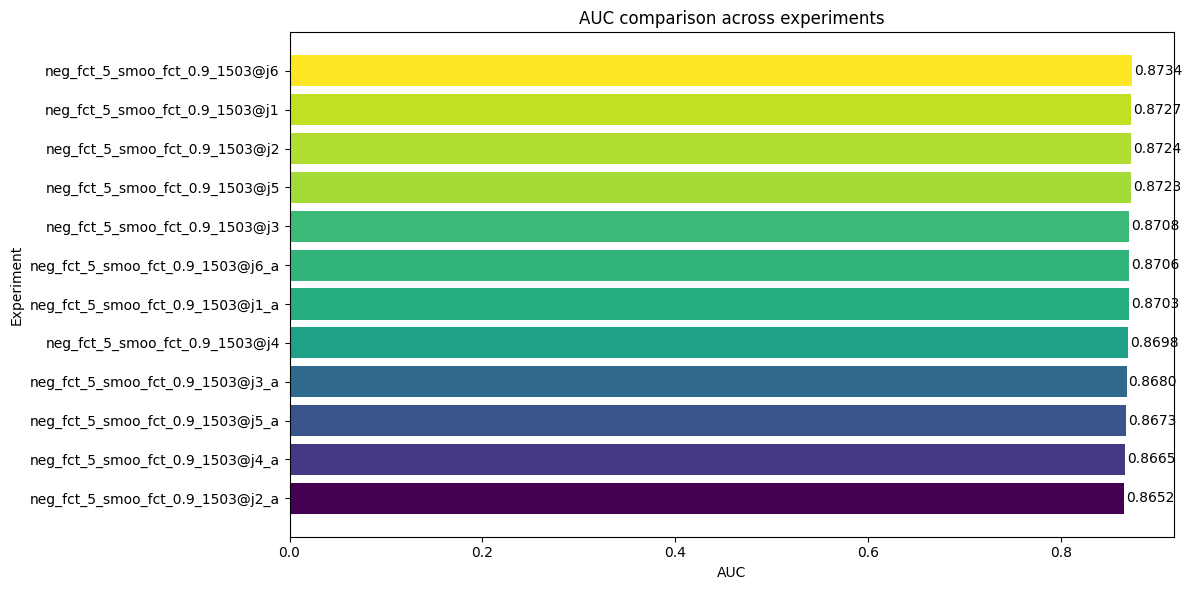

In [20]:

df = exp_df.copy()
df["folds_statistics"] = df["folds_statistics"].apply(parse_if_string)
df = df[df["folds_statistics"].apply(lambda x: isinstance(x, (list, tuple)) and len(x) == 5)].copy()
metric_names = ["AUC", "AUPR", "Precision", "Sensitivity", "Specificity"]

for i, metric in enumerate(metric_names):
    df[metric] = df["folds_statistics"].apply(lambda x: x[i])


df["exp_clean"] = df["exp"].str.replace("dataset_", "", regex=False) # remove "dataset_" from experiment names
df = df.sort_values("AUC", ascending=True).reset_index(drop=True) # sort by AUC

# create colors according to AUC values
norm = mcolors.Normalize(vmin=df["AUC"].min(), vmax=df["AUC"].max())
colors = cm.viridis(norm(df["AUC"]))

# plotting pipeline ..
plt.figure(figsize=(12,6))
bars = plt.barh(df["exp_clean"], df["AUC"], color=colors)

plt.title("AUC comparison across experiments")
plt.xlabel("AUC")
plt.ylabel("Experiment")

for bar, value in zip(bars, df["AUC"]):
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{value:.4f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [21]:
exp_df

,exp,val_res,fold1,fold2,fold3,fold4,fold5,fold1_avg,fold2_avg,fold3_avg,fold4_avg,fold5_avg,folds_statistics,AUC_statistics
0,dataset_neg_fct_5_smoo_fct_0.9_1503@j2,"{""fold1"": [[0.9870957605022931, 0.947628508007...","[[0.6824265053651657, 0.6653360699265691, 0.86...","[[0.8487502252293029, 0.7935045520580875, 0.85...","[[0.9073943741272916, 0.8927620617085753, 0.94...","[[0.9668525379959322, 0.9519494170034655, 0.96...","[[0.9306467986568248, 0.9283141228187478, 0.96...","[0.73344, 0.70035, 0.86061, 0.13188, 0.97674]","[0.83132, 0.77454, 0.83864, 0.2065, 0.96007]","[0.89847, 0.88391, 0.92209, 0.3526, 0.96997]","[0.96394, 0.94947, 0.95951, 0.59788, 0.97475]","[0.93498, 0.93091, 0.96659, 0.50444, 0.98254]","[0.87243, 0.84784, 0.90949, 0.35866, 0.97281]","[0.87243, 0.00679, 0.08243]"
1,dataset_neg_fct_5_smoo_fct_0.9_1503@j4,"{""fold1"": [[0.9882161502896648, 0.952728321791...","[[0.6783838183484806, 0.6620224861231838, 0.86...","[[0.8446870455001988, 0.7952797381935002, 0.86...","[[0.8950638484752939, 0.8768462983775632, 0.89...","[[0.9633692614192145, 0.9483151762604894, 0.95...","[[0.9235744334578224, 0.9238609428227462, 0.97...","[0.73741, 0.69114, 0.79616, 0.12973, 0.9629]","[0.8202, 0.76525, 0.84061, 0.19322, 0.96388]","[0.89474, 0.88142, 0.91908, 0.35134, 0.96896]","[0.9651, 0.95028, 0.95833, 0.60007, 0.9739]","[0.93175, 0.92943, 0.96326, 0.51014, 0.98048]","[0.86984, 0.8435, 0.89549, 0.3569, 0.97002]","[0.86984, 0.00671, 0.08189]"
2,dataset_neg_fct_5_smoo_fct_0.9_1503@j5,"{""fold1"": [[0.9883505597281943, 0.952452278910...","[[0.730374727884913, 0.6926091143460115, 0.836...","[[0.8360985887929346, 0.7845121412963442, 0.85...","[[0.899679350029278, 0.8805304907317271, 0.890...","[[0.9647130156439735, 0.9497697359149242, 0.95...","[[0.9320016777132869, 0.9309840308815354, 0.96...","[0.73835, 0.69385, 0.78457, 0.12563, 0.96241]","[0.82556, 0.76827, 0.83795, 0.20418, 0.95989]","[0.89919, 0.88486, 0.91841, 0.35176, 0.96862]","[0.96599, 0.95143, 0.95939, 0.60678, 0.97432]","[0.93245, 0.92994, 0.9652, 0.50783, 0.98162]","[0.87231, 0.84567, 0.8931, 0.35924, 0.96937]","[0.87231, 0.00665, 0.08154]"
3,dataset_neg_fct_5_smoo_fct_0.9_1503@j3,"{""fold1"": [[0.9887220524819077, 0.954915661273...","[[0.6868571929003444, 0.6953161318295789, 0.87...","[[0.8271329538273463, 0.7738090033175761, 0.83...","[[0.9049831651727399, 0.8872107798438864, 0.90...","[[0.9679387554093437, 0.9530693111775712, 0.95...","[[0.932203053538644, 0.930425346271282, 0.9659...","[0.7346, 0.69159, 0.78113, 0.14448, 0.95703]","[0.81759, 0.763, 0.84255, 0.19972, 0.9624]","[0.90244, 0.888, 0.91642, 0.35705, 0.96745]","[0.96556, 0.95084, 0.95876, 0.61228, 0.97363]","[0.93355, 0.93075, 0.96453, 0.51236, 0.98111]","[0.87075, 0.84484, 0.89268, 0.36518, 0.96832]","[0.87075, 0.00706, 0.08402]"
4,dataset_neg_fct_5_smoo_fct_0.9_1503@j1,"{""fold1"": [[0.9880948084354368, 0.952343636811...","[[0.7238813739162155, 0.6913263422011363, 0.88...","[[0.8354459626408168, 0.7810172662725587, 0.87...","[[0.9019906197919012, 0.8844658963023292, 0.93...","[[0.9616815255696092, 0.9466335961397551, 0.95...","[[0.9264212215661504, 0.9252393370070784, 0.97...","[0.74147, 0.7062, 0.85711, 0.12757, 0.97706]","[0.82605, 0.76918, 0.84728, 0.20046, 0.9624]","[0.89616, 0.88165, 0.92604, 0.34362, 0.9724]","[0.96579, 0.9515, 0.96122, 0.60393, 0.97565]","[0.93376, 0.93032, 0.96823, 0.5058, 0.98339]","[0.87265, 0.84777, 0.91198, 0.35628, 0.97418]","[0.87265, 0.00647, 0.08043]"
5,dataset_neg_fct_5_smoo_fct_0.9_1503@j6,"{""fold1"": [[0.9886094223505473, 0.955574571490...","[[0.7014828985436641, 0.6996680809228946, 0.88...","[[0.8593038884276537, 0.8040586509357075, 0.84...","[[0.8997659170758073, 0.8823510260755983, 0.90...","[[0.9659196477746596, 0.9514438772700716, 0.95...","[[0.9343914647592306, 0.9331078131621698, 0.96...","[0.74124, 0.70192, 0.82983, 0.13366, 0.97065]","[0.83357, 0.77628, 0.8396, 0.20752, 0.96054]","[0.89619, 0.88106, 0.92372, 0.34421, 0.97156]","[0.96551, 0.95112, 0.96084, 0.60

In [24]:
exp_df.to_csv(PREPROCESSED_EXP_1503_PATH, index=False)